## Long Short-Term Memory Network Implementation

In [2]:
# importing the Libraries
import numpy as np
import matplotlib.pyplot as plt
import torch

In [11]:
class LSTMFromScratch:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.hidden_size = hidden_size
        self.lr = lr

        concat_size = hidden_size + input_size
        self.W_f = np.random.randn(hidden_size, concat_size) * 0.01  # forget
        self.W_i = np.random.randn(hidden_size, concat_size) * 0.01  # input
        self.W_g = np.random.randn(hidden_size, concat_size) * 0.01  # candidate
        self.W_o = np.random.randn(hidden_size, concat_size) * 0.01  # output

        self.b_f = np.zeros(hidden_size)
        self.b_i = np.zeros(hidden_size)
        self.b_g = np.zeros(hidden_size)
        self.b_o = np.zeros(hidden_size)

        # output layer
        self.W_y = np.random.randn(output_size, hidden_size) * 0.01
        self.b_y = np.zeros(output_size)

    def tanh(self, z):
        return np.tanh(z)

    def tanh_derivative(self, z):
        return 1 - np.tanh(z) ** 2

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, inputs, h_prev, c_prev):
        self.hidden_states = [h_prev]
        self.cell_states = [c_prev]
        self.outputs = []

        for x in inputs:
            combined = np.concatenate([self.hidden_states[-1], x])

            f_t = self.sigmoid(self.W_f @ combined + self.b_f)
            i_t = self.sigmoid(self.W_i @ combined + self.b_i)
            g_t = self.tanh(self.W_g @ combined + self.b_g)
            o_t = self.sigmoid(self.W_o @ combined + self.b_o)

            c_t = f_t * self.cell_states[-1] + i_t * g_t
            h_t = o_t * self.tanh(c_t)
            y_t = self.softmax(self.W_y @ h_t + self.b_y)

            self.cell_states.append(c_t)
            self.hidden_states.append(h_t)
            self.outputs.append(y_t)

        return self.outputs, self.hidden_states, self.cell_states

Epoch 0: loss=2.3292
Sample: t rho seaastoec ehnaonen e a htet  t t an
Epoch 100: loss=0.0374
Sample: the cat sat sat sat sat sat sat sat sat s
Epoch 200: loss=0.0361
Sample: t on the mat sat sat sat sat sat sat sat 
Epoch 300: loss=0.0359
Sample: t on the mat sat sat sat sat sat sat sat 
Epoch 400: loss=0.0357
Sample: t on the mat sat sat sat sat sat sat sat 


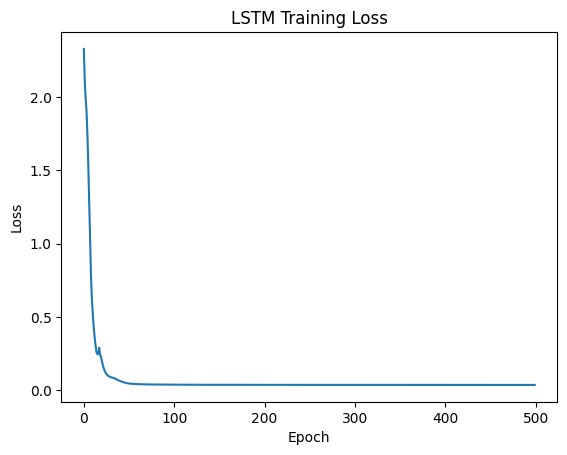

In [12]:
import torch
import torch.nn as nn

# same corpus as rnn
text = "the cat sat on the mat the cat ate the rat"
chars = sorted(set(text))
vocab_size = len(chars)
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}

class LSTMNet(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(vocab_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

model = LSTMNet(vocab_size=vocab_size, hidden_size=64)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

seq_length = 10
losses = []

for epoch in range(500):
    epoch_loss = 0
    n_batches = 0

    for i in range(0, len(text) - seq_length, seq_length):

        inputs = torch.zeros(1, seq_length, vocab_size)
        targets = torch.zeros(seq_length, dtype=torch.long)

        for j in range(seq_length):
            inputs[0, j, char_to_idx[text[i+j]]] = 1
            targets[j] = char_to_idx[text[i+j+1]]

        optimizer.zero_grad()
        output, _ = model(inputs)
        loss = criterion(output.squeeze(), targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    losses.append(epoch_loss / n_batches)

    if epoch % 100 == 0:
        # sample
        model.eval()
        with torch.no_grad():
            x = torch.zeros(1, 1, vocab_size)
            x[0, 0, char_to_idx['t']] = 1
            hidden = None
            result = ['t']
            for _ in range(40):
                out, hidden = model(x, hidden)
                probs = torch.softmax(out[0, 0], dim=0).numpy()
                next_idx = np.random.choice(vocab_size, p=probs)
                result.append(idx_to_char[next_idx])
                x = torch.zeros(1, 1, vocab_size)
                x[0, 0, next_idx] = 1
        print(f"Epoch {epoch}: loss={losses[-1]:.4f}")
        print(f"Sample: {''.join(result)}")
        model.train()

# plot
import matplotlib.pyplot as plt
plt.plot(losses)
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [13]:
import urllib.request

# downloading a larger text
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = urllib.request.urlopen(url)
text = response.read().decode('utf-8')[:10000]  # first 10k characters

print(f"Corpus size: {len(text)} characters")
print(text[:200])

Corpus size: 10000 characters
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


TRAINING RNN
Epoch 0: loss=4.0858
Epoch 100: loss=1.8504
Epoch 200: loss=1.5218

TRAINING LSTM
Epoch 0: loss=4.0238
Epoch 100: loss=1.8082
Epoch 200: loss=1.3915


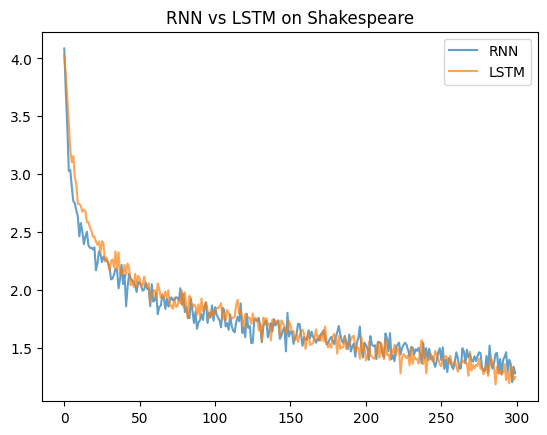


RNN sample:
First Citizen:
Becthe frat tizen:
Of you. With give hake actionsumed us morath, you
who denity youad thoor abubling thoulms,
The pitizent their it to
'S:
He's, gut the fromed.

MENENIUS:
Fornd Citizen:

LSTM sample:
First Citizen:
Let, senation not youar not wing seak, not arest forth, incestorest
They.

MENENIUS:
I selvest in this this mak mise, you, avery to they, wholese, the rignedic then?

First the hang at b


In [15]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# data preparation
data = torch.tensor([char_to_idx[c] for c in text], dtype=torch.long)

def get_batch(data, seq_length, batch_size=32):
    ix = torch.randint(0, len(data) - seq_length, (batch_size,))
    x = torch.stack([data[i:i+seq_length] for i in ix])
    y = torch.stack([data[i+1:i+seq_length+1] for i in ix])
    return x, y

# RNN
class RNNNet(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embed(x)
        out, hidden = self.rnn(x, hidden)
        return self.fc(out), hidden

# LSTM
class LSTMNet(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embed(x)
        out, hidden = self.lstm(x, hidden)
        return self.fc(out), hidden

def train(model, data, epochs=300, seq_length=25):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    losses = []

    for epoch in range(epochs):
        x, y = get_batch(data, seq_length)
        optimizer.zero_grad()
        out, _ = model(x)
        loss = criterion(out.reshape(-1, vocab_size), y.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
        optimizer.step()
        losses.append(loss.item())

        if epoch % 100 == 0:
            print(f"Epoch {epoch}: loss={loss.item():.4f}")

    return losses

def sample(model, start_char, length=200):
    model.eval()
    with torch.no_grad():
        x = torch.tensor([[char_to_idx[start_char]]])
        hidden = None
        result = [start_char]
        for _ in range(length):
            out, hidden = model(x, hidden)
            probs = torch.softmax(out[0, -1], dim=0).numpy()
            next_idx = np.random.choice(vocab_size, p=probs)
            result.append(idx_to_char[next_idx])
            x = torch.tensor([[next_idx]])
    model.train()
    return ''.join(result)

# training both
print("TRAINING RNN")
rnn = RNNNet(vocab_size, hidden_size=128)
rnn_losses = train(rnn, data, epochs=300)

print("\nTRAINING LSTM")
lstm = LSTMNet(vocab_size, hidden_size=128)
lstm_losses = train(lstm, data, epochs=300)

# comparison
plt.plot(rnn_losses, label='RNN', alpha=0.7)
plt.plot(lstm_losses, label='LSTM', alpha=0.7)
plt.title('RNN vs LSTM on Shakespeare')
plt.legend()
plt.show()

print("\nRNN sample:")
print(sample(rnn, 'F'))
print("\nLSTM sample:")
print(sample(lstm, 'F'))